# Type A — Challenge-Only Insurance Hedge

**Hedge Type:** You buy a challenge, hedge through all phases, get funded, and stop hedging.

**Goal:** The first funded payout covers all challenge costs.

## EV Formula

$$\text{funded payout} = \text{account size} \times \text{funded target \%} \times \text{profit split \%}$$

$$\text{EV}_A = \text{funded payout} - (\text{challenge fee} + \text{total hedge losses})$$

## Key Question

> "If I insure my way through the challenge, is the first funded payout large enough to cover what I spent getting there?"

## Worked Example

| Metric | Value |
|--------|-------|
| Account size | $100,000 |
| Challenge fee | $500 |
| Hedge losses across phases | $800 |
| Total cost to get funded | $1,300 |
| Funded target | 8% |
| Profit split | 80% |
| Funded payout | $6,400 |
| **EV_A** | **$5,100** |

---

**Reference:** [hedging-explained.md](../Product/hedging-explained.md) §5 Type A

## 0 — Setup & Imports

In [1]:
import sys, os, json, math, glob, importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

WS_ROOT = os.environ.get(
    "WORKSPACE_ROOT",
    r"C:\Users\sossi\Desktop\Business\Orchestrator Hedge Edge"
)
if WS_ROOT not in sys.path:
    sys.path.insert(0, WS_ROOT)

STRATEGY_ROOT = os.path.join(WS_ROOT, "Business", "STRATEGY")
DATA_DIR = os.path.join(STRATEGY_ROOT, "resources", "PropFirmData")

exec_path = os.path.join(STRATEGY_ROOT, "executions")
if exec_path not in sys.path:
    sys.path.insert(0, exec_path)

if "hedge_arbitrage_model" in sys.modules:
    importlib.reload(sys.modules["hedge_arbitrage_model"])

from hedge_arbitrage_model import (
    compute_phase_economics,
    compute_funded_target_sensitivity,
    DEFAULT_FUNDED_TARGET_PCT,
    DEFAULT_SPREAD_COST_PCT,
    DEFAULT_LEVERAGE,
)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 120

# ── Tuneable assumptions ──
FUNDED_TARGET = 0.08   # 8% of funded account
SPREAD_COST   = 0.0003 # 3 pips per side
RESIZES_PER_PHASE = 20

print("Type A notebook ready.")
print(f"Defaults: funded_target={FUNDED_TARGET*100:.0f}%, spread={SPREAD_COST}")

python-dotenv could not parse statement starting at line 129
python-dotenv could not parse statement starting at line 130


Type A notebook ready.
Defaults: funded_target=8%, spread=0.0003


## 1 — Load Challenge Data & Classify Drawdown

In [2]:
json_files = glob.glob(os.path.join(DATA_DIR, "propmatch_challenges_*.json"))
if not json_files:
    raise FileNotFoundError("No scraped data found.")

latest = max(json_files, key=os.path.getmtime)
print(f"Loading: {os.path.basename(latest)}")

with open(latest, 'r', encoding='utf-8') as f:
    raw = json.load(f)

challenges = raw.get("challenges", raw if isinstance(raw, list) else [])
print(f"Loaded {len(challenges)} challenges")

def classify_drawdown(dd_type_str):
    """Only explicit 'trailing' keyword → trailing. Everything else → static."""
    if not dd_type_str or dd_type_str == "-":
        return "static"
    if "trailing" in dd_type_str.lower():
        return "trailing"
    return "static"

df_raw = pd.DataFrame(challenges)
df_raw["dd_category"] = df_raw["drawdown_type"].fillna("-").apply(classify_drawdown)

print(f"\nDrawdown breakdown:")
for cat, cnt in df_raw["dd_category"].value_counts().items():
    print(f"  {cat}: {cnt}")

Loading: propmatch_challenges_20260324_183523.json
Loaded 224 challenges

Drawdown breakdown:
  static: 223
  trailing: 1


## 2 — Compute Type A Economics (Compounding Hedge v3)

For each challenge, walk Phase 1 → Phase 2 → Funded. You always pass.

- **Static DD:** Hedge = insured/DD (constant). Cost = hedge × target + spread.
- **Trailing DD:** Hedge compounds daily. Each resize: insured *= (1 + δ/DD).

$$\text{EV}_A = \text{funded payout} - \text{total cost}$$

In [3]:
def compute_type_a(challenge, funded_target_pct=FUNDED_TARGET,
                   spread_cost_pct=SPREAD_COST,
                   resizes_per_phase=RESIZES_PER_PHASE):
    """Type A: Challenge-Only Insurance Hedge.
    
    Deterministic model — you always pass via the hedge.
    EV = funded payout - (fee + all hedge losses).
    """
    S = challenge.get("account_size", 0)
    fee = challenge.get("fee_assumed") or challenge.get("fee_original") or challenge.get("fee_discounted") or 0
    targets = challenge.get("profit_targets") or []
    steps = challenge.get("steps") or len(targets) or 2
    dd_max_pct = (challenge.get("max_drawdown_pct") or 10.0) / 100.0
    split = (challenge.get("profit_split_pct") or 80.0) / 100.0
    leverage = 100
    dd_category = classify_drawdown(challenge.get("drawdown_type", ""))

    if targets:
        phase_targets = [t / 100.0 for t in targets]
    else:
        phase_targets = [0.08 / steps] * steps

    L = fee  # insured base
    phases = []

    for phase_idx in range(steps):
        phase_target = phase_targets[phase_idx] if phase_idx < len(phase_targets) else phase_targets[-1]
        L_start = L

        if dd_category == "trailing":
            N = resizes_per_phase
            daily_move = phase_target / N
            total_spread = 0.0
            for _ in range(N):
                hedge_size = L / dd_max_pct
                pnl_loss = hedge_size * daily_move
                day_spread = hedge_size * spread_cost_pct * 2
                total_spread += day_spread
                L += pnl_loss + day_spread
            final_hedge = L / dd_max_pct
            avg_hedge = (L_start / dd_max_pct + final_hedge) / 2
        else:
            hedge_size = L / dd_max_pct if dd_max_pct > 0 else 0
            pnl_loss = hedge_size * phase_target
            spread_loss = hedge_size * spread_cost_pct * 2
            L += pnl_loss + spread_loss
            total_spread = spread_loss
            avg_hedge = hedge_size
            final_hedge = hedge_size

        phase_cost = L - L_start
        margin = final_hedge / leverage
        buffer = final_hedge * dd_max_pct * 1.5
        capital = margin + buffer

        phases.append({
            "phase": phase_idx + 1,
            "phase_target_pct": round(phase_target * 100, 2),
            "dd_pct": round(dd_max_pct * 100, 2),
            "insured_base": round(L_start, 2),
            "avg_hedge_size": round(avg_hedge, 2),
            "final_hedge_size": round(final_hedge, 2),
            "spread_cost": round(total_spread, 2),
            "phase_cost": round(phase_cost, 2),
            "insured_after": round(L, 2),
            "capital_required": round(capital, 2),
        })

    total_cost = L
    funded_payout = S * funded_target_pct * split
    EV = funded_payout - total_cost
    breakeven_payout = total_cost / split if split > 0 else 0
    breakeven_pct = (breakeven_payout / S) * 100 if S > 0 else 0
    capital_required = max(ph["capital_required"] for ph in phases) if phases else 0

    return {
        "firm": challenge.get("firm"),
        "account_size": S,
        "fee": round(fee, 2),
        "steps": steps,
        "drawdown_type": challenge.get("drawdown_type", "-"),
        "dd_category": dd_category,
        "profit_split_pct": round(split * 100, 1),
        "max_drawdown_pct": round(dd_max_pct * 100, 2),
        "funded_target_pct": round(funded_target_pct * 100, 2),
        "phases": phases,
        "total_cost": round(total_cost, 2),
        "funded_payout": round(funded_payout, 2),
        "EV": round(EV, 2),
        "breakeven_payout": round(breakeven_payout, 2),
        "breakeven_pct": round(breakeven_pct, 2),
        "capital_required": round(capital_required, 2),
        "capital_efficiency": round(EV / capital_required, 4) if capital_required > 0 else 0,
        "cost_efficiency": round(EV / fee, 4) if fee > 0 else 0,
    }


# Run on all challenges
results_a = [compute_type_a(c) for c in challenges]
df_a = pd.DataFrame(results_a)

pos = (df_a["EV"] > 0).sum()
print(f"✅ Positive EV: {pos}/{len(df_a)} challenges")
print(f"📊 Average EV: ${df_a['EV'].mean():,.2f}")
print(f"📊 Best EV: {df_a.loc[df_a['EV'].idxmax(), 'firm']} → ${df_a['EV'].max():,.2f}")
print(f"🎯 Funded target: {FUNDED_TARGET*100:.0f}%")

print(f"\n── EV by Drawdown Category ──")
for cat in ["static", "trailing"]:
    mask = df_a["dd_category"] == cat
    if mask.any():
        print(f"  {cat:10s} ({mask.sum()} challenges): avg EV = ${df_a.loc[mask, 'EV'].mean():,.2f}")

✅ Positive EV: 213/224 challenges
📊 Average EV: $2,777.05
📊 Best EV: AquaFunded → $22,475.34
🎯 Funded target: 8%

── EV by Drawdown Category ──
  static     (223 challenges): avg EV = $2,791.08
  trailing   (1 challenges): avg EV = $-352.80


## 3 — Type A Rankings (Top 30)

In [4]:
rank_cols = [
    "firm", "account_size", "dd_category", "fee", "steps",
    "max_drawdown_pct", "profit_split_pct",
    "total_cost", "funded_payout", "EV", "breakeven_pct",
    "capital_required", "capital_efficiency"
]

df_a.sort_values("EV", ascending=False)[rank_cols].head(30).style.format({
    "fee": "${:,.0f}",
    "total_cost": "${:,.2f}",
    "funded_payout": "${:,.2f}",
    "EV": "${:,.2f}",
    "breakeven_pct": "{:.1f}%",
    "capital_required": "${:,.0f}",
    "capital_efficiency": "{:.4f}",
    "max_drawdown_pct": "{:.1f}%",
    "profit_split_pct": "{:.0f}%",
    "account_size": "${:,}",
}).bar(subset=["EV"], color="#5fba7d").set_caption(
    f"Type A Rankings — Top 30 by EV (Funded Target: {FUNDED_TARGET*100:.0f}%)"
)

,firm,account_size,dd_category,fee,steps,max_drawdown_pct,profit_split_pct,total_cost,funded_payout,EV,breakeven_pct,capital_required,capital_efficiency
216,AquaFunded,"$400,000",static,"$2,699",1,6.0%,90%,"$6,324.66","$28,800.00","$22,475.34",1.8%,"$4,498",4.9964
200,Goat Funded Trader,"$400,000",static,"$2,998",1,6.0%,80%,"$7,025.31","$25,600.00","$18,574.69",2.2%,"$4,997",3.7174
217,AquaFunded,"$300,000",static,"$2,099",1,6.0%,90%,"$4,918.66","$21,600.00","$16,681.34",1.8%,"$3,498",4.7684
151,Nordic Funder,"$500,000",static,"$1,932",3,5.0%,80%,"$15,735.88","$32,000.00","$16,264.12",3.9%,"$13,296",1.2233
199,Goat Funded Trader,"$300,000",static,"$2,398",1,6.0%,80%,"$5,619.31","$19,200.00","$13,580.69",2.3%,"$3,997",3.3980
184,FundingPips,"$200,000",static,$998,1,5.0%,95%,"$2,606.78","$15,200.00","$12,593.22",1.4%,"$1,697",7.4226
158,FXIFY,"$400,000",static,"$1,599",3,5.0%,80%,"$13,023.64","$25,600.00","$12,576.36",4.1%,"$11,004",1.1429
198,Goat Funded Trader,"$250,000",static,"$2,088",1,6.0%,80%,"$4,892.88","$16,000.00","$11,107.12",2.5%,"$3,480",3.1917
123,AquaFunded,"$200,000",static,$677,3,8.0%,90%,"$3,675.15","$14,400.00","$10,724.85",2.0%,"$3,398",3.1562
71,BrightFunded,"$200,000",static,$975,2,10.0%,80%,"$2,651.84","$12,800.00","$10,148.16",1.7%,"$2,817",3.6020


## 4 — EV Bar Chart (Top 15 & Bottom 5)

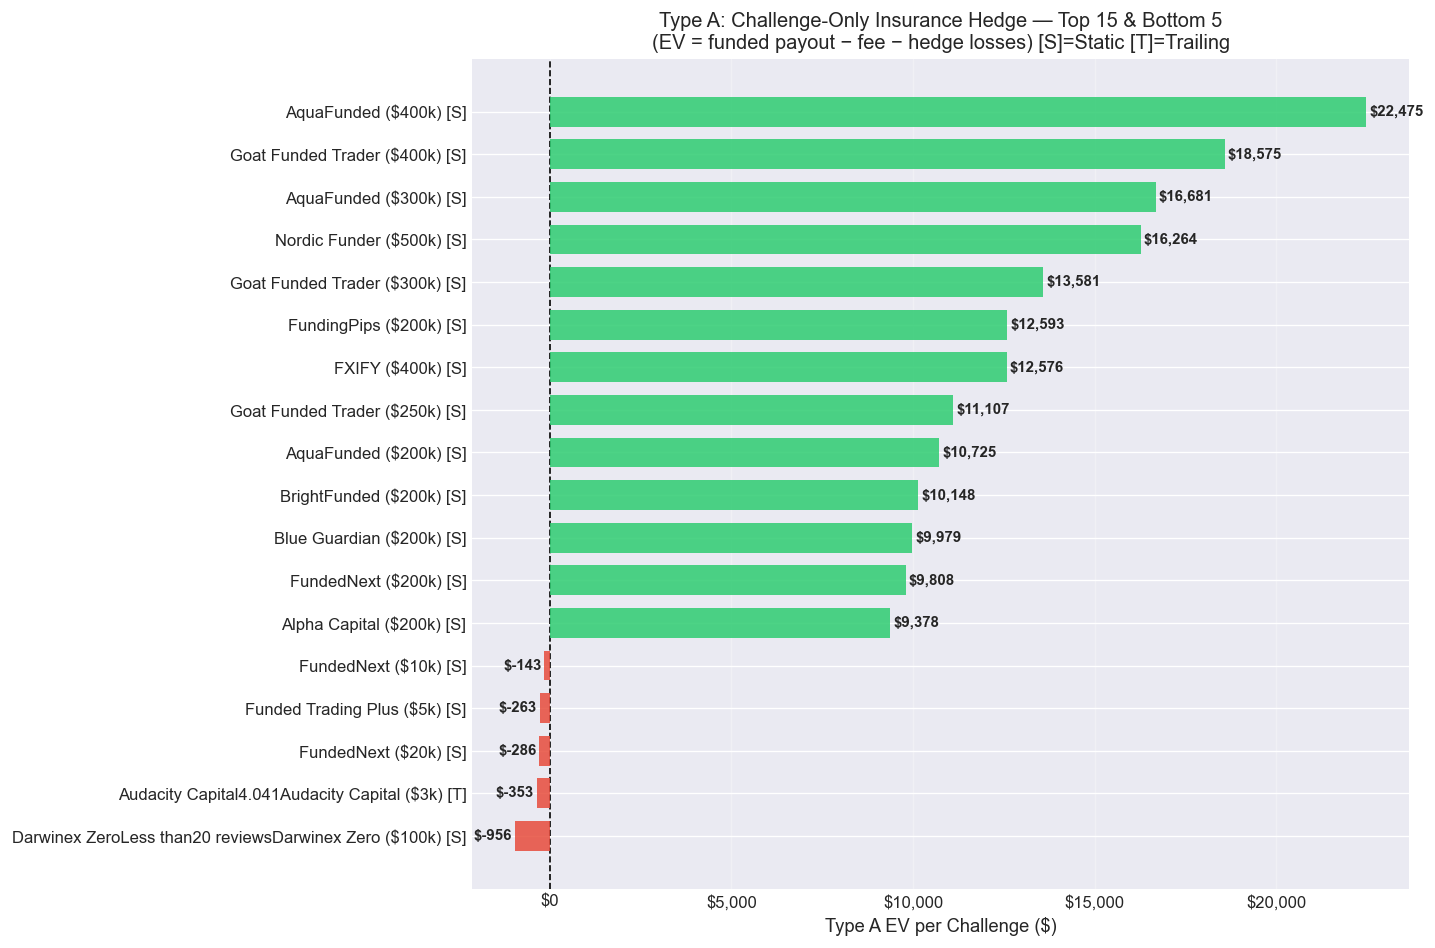

In [5]:
df_sorted = df_a.sort_values("EV", ascending=False)
df_show = pd.concat([df_sorted.head(15), df_sorted.tail(5)]).drop_duplicates(
    subset=["firm", "account_size"]
).sort_values("EV", ascending=True).copy()
df_show["label"] = df_show.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k) [{r['dd_category'][:1].upper()}]", axis=1
)

fig, ax = plt.subplots(figsize=(12, 8))
y = range(len(df_show))
colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in df_show["EV"]]
bars = ax.barh(y, df_show["EV"], height=0.7, color=colors, alpha=0.85, zorder=3)

ax.set_yticks(list(y))
ax.set_yticklabels(df_show["label"], fontsize=10)
ax.axvline(x=0, color="black", linewidth=1, linestyle="--")
ax.set_xlabel("Type A EV per Challenge ($)", fontsize=11)
ax.set_title(f"Type A: Challenge-Only Insurance Hedge — Top 15 & Bottom 5\n"
             f"(EV = funded payout − fee − hedge losses) [S]=Static [T]=Trailing", fontsize=12)
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(axis='x', alpha=0.3)

for bar, val in zip(bars, df_show["EV"]):
    offset = 80 if val >= 0 else -80
    ha = 'left' if val >= 0 else 'right'
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f"${val:,.0f}", va="center", ha=ha, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 5 — Phase-by-Phase Cost Stack Growth

How the insured base (cost stack) grows through each phase:
- Phase 1: insured base = challenge fee only
- Phase 2: insured base = fee + Phase 1 hedge loss
- After all phases: total cost carried into funded stage

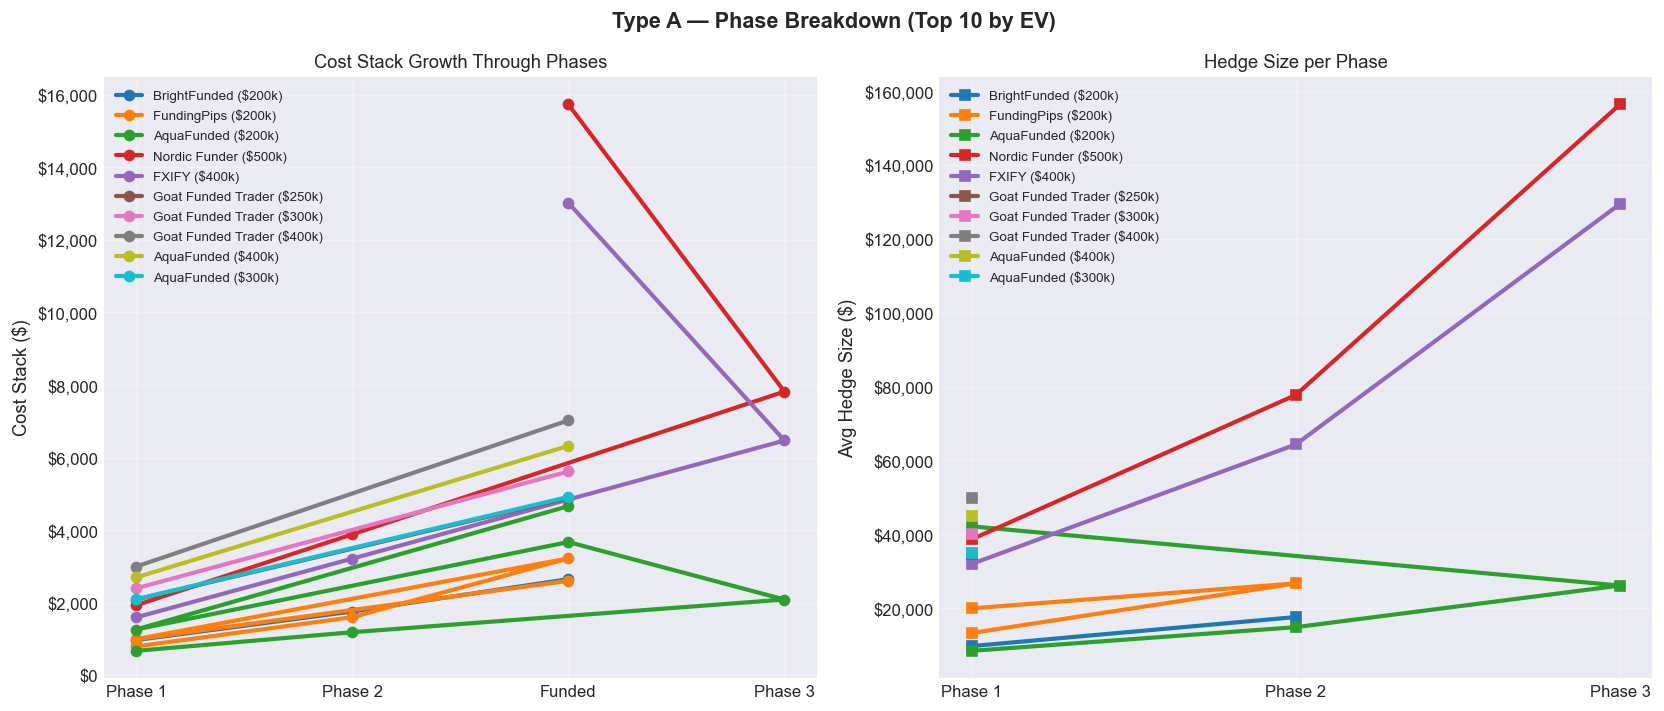

In [6]:
top10 = df_a.nlargest(10, "EV")
top10_keys = set(zip(top10["firm"], top10["account_size"]))

phase_rows = []
for r in results_a:
    if (r["firm"], r["account_size"]) not in top10_keys:
        continue
    label = f"{r['firm']} (${r['account_size']/1000:.0f}k)"
    for ph in r.get("phases", []):
        phase_rows.append({"label": label, "phase": f"Phase {ph['phase']}",
                           "insured_base": ph["insured_base"], "hedge_size": ph["avg_hedge_size"]})
    phase_rows.append({"label": label, "phase": "Funded",
                       "insured_base": r["total_cost"], "hedge_size": 0})

df_ph = pd.DataFrame(phase_rows)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
colors = plt.cm.tab10.colors

for i, label in enumerate(df_ph["label"].unique()):
    sub = df_ph[df_ph["label"] == label]
    ax1.plot(sub["phase"], sub["insured_base"], marker="o", linewidth=2.5,
             label=label, color=colors[i % 10])

ax1.set_ylabel("Cost Stack ($)", fontsize=11)
ax1.set_title("Cost Stack Growth Through Phases", fontsize=11)
ax1.legend(fontsize=8, loc="upper left")
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

for i, label in enumerate(df_ph["label"].unique()):
    sub = df_ph[(df_ph["label"] == label) & (df_ph["phase"] != "Funded")]
    ax2.plot(sub["phase"], sub["hedge_size"], marker="s", linewidth=2.5,
             label=label, color=colors[i % 10])

ax2.set_ylabel("Avg Hedge Size ($)", fontsize=11)
ax2.set_title("Hedge Size per Phase", fontsize=11)
ax2.legend(fontsize=8, loc="upper left")
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)

plt.suptitle("Type A — Phase Breakdown (Top 10 by EV)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 6 — Static vs Trailing Cost Comparison

For the same fee, trailing DD compounds costs exponentially while static stays linear.

- **Static:** $L_{\text{after}} = L \times (1 + \text{target}/DD)$
- **Trailing:** $L_{\text{after}} \approx L \times (1 + \delta/DD)^N$ where $N$ = resizes per phase

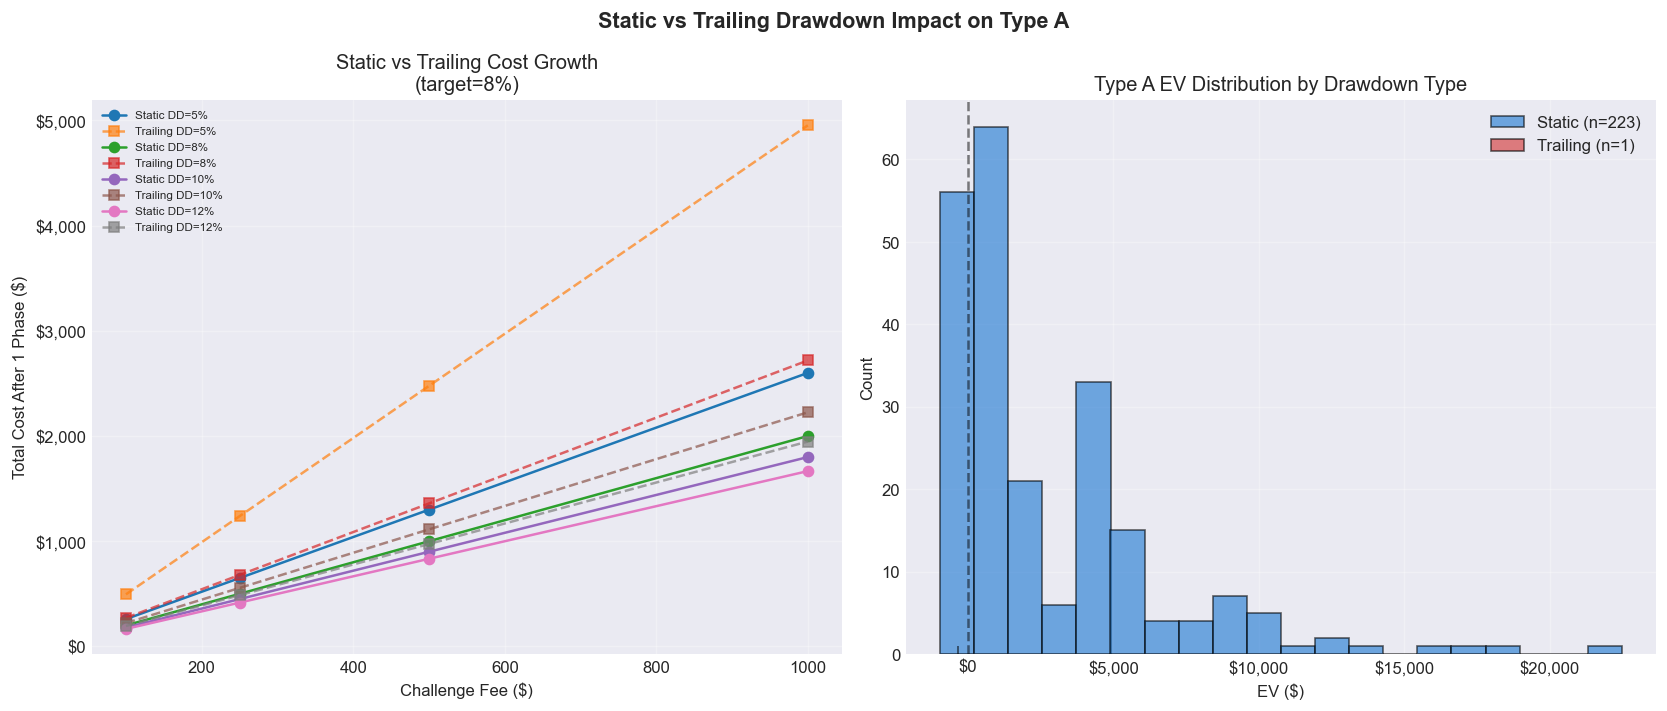

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left: theoretical cost multiplier
sample_fees = [100, 250, 500, 1000]
dd_vals = [0.05, 0.08, 0.10, 0.12]
target = 0.08

for dd in dd_vals:
    static_mult = [1 + target / dd] * len(sample_fees)
    trailing_mult = [math.exp(target / dd)] * len(sample_fees)
    ax1.plot(sample_fees, [f * sm for f, sm in zip(sample_fees, static_mult)],
             'o-', label=f"Static DD={dd*100:.0f}%")
    ax1.plot(sample_fees, [f * tm for f, tm in zip(sample_fees, trailing_mult)],
             's--', label=f"Trailing DD={dd*100:.0f}%", alpha=0.7)

ax1.set_xlabel("Challenge Fee ($)")
ax1.set_ylabel("Total Cost After 1 Phase ($)")
ax1.set_title(f"Static vs Trailing Cost Growth\n(target={target*100:.0f}%)")
ax1.legend(fontsize=7)
ax1.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

# Right: actual EV comparison from data
for cat, color, lbl in [("static", "#1976d2", "Static"), ("trailing", "#d32f2f", "Trailing")]:
    mask = df_a["dd_category"] == cat
    if mask.any():
        ax2.hist(df_a.loc[mask, "EV"], bins=20, alpha=0.6, color=color,
                 label=f"{lbl} (n={mask.sum()})", edgecolor='black')

ax2.axvline(x=0, color="black", linestyle="--", alpha=0.5)
ax2.set_xlabel("EV ($)")
ax2.set_ylabel("Count")
ax2.set_title("Type A EV Distribution by Drawdown Type")
ax2.legend()
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)

plt.suptitle("Static vs Trailing Drawdown Impact on Type A", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 7 — Funded Target Sensitivity

What happens to Type A EV as you change the funded profit target from 1% to 20%?

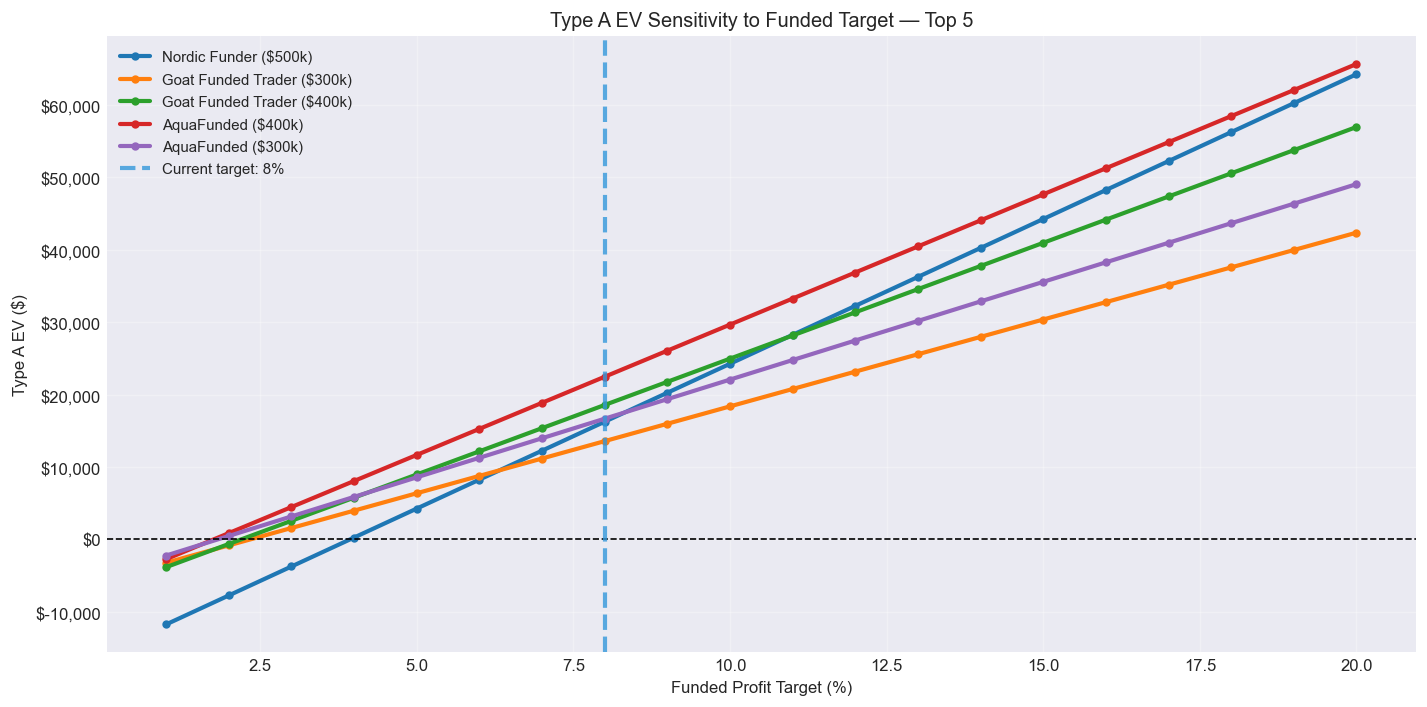

In [8]:
top5 = df_a.nlargest(5, "EV")
top5_keys = set(zip(top5["firm"], top5["account_size"]))
top5_challenges = [c for c in challenges if (c["firm"], c["account_size"]) in top5_keys]

fig, ax = plt.subplots(figsize=(12, 6))
target_sweep = [r / 100 for r in range(1, 21)]
colors = plt.cm.tab10.colors

for i, ch in enumerate(top5_challenges):
    evs = [compute_type_a(ch, funded_target_pct=t)["EV"] for t in target_sweep]
    label = f"{ch['firm']} (${ch['account_size']/1000:.0f}k)"
    ax.plot([t * 100 for t in target_sweep], evs, marker="o", markersize=4,
            label=label, linewidth=2.5, color=colors[i % 10])

ax.axhline(y=0, color="black", linewidth=1, linestyle="--")
ax.axvline(x=FUNDED_TARGET * 100, color="#3498db", linewidth=2.5, linestyle="--",
           alpha=0.8, label=f"Current target: {FUNDED_TARGET*100:.0f}%")

ax.set_xlabel("Funded Profit Target (%)")
ax.set_ylabel("Type A EV ($)")
ax.set_title("Type A EV Sensitivity to Funded Target — Top 5")
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 8 — Capital Efficiency

Which challenges give the most Type A EV per dollar of capital deployed?

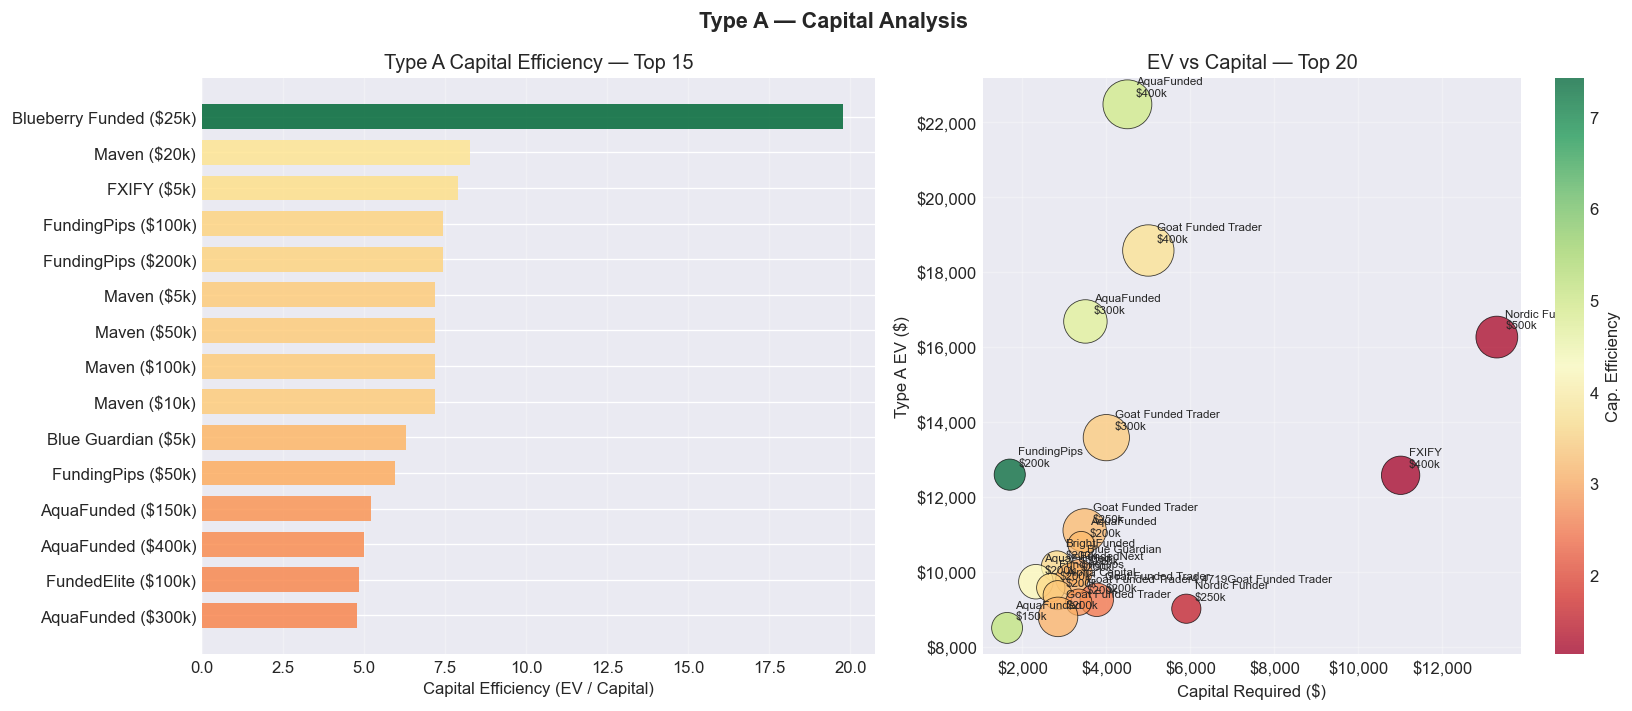

In [9]:
df_cap = df_a[df_a["capital_efficiency"] > 0].nlargest(15, "capital_efficiency").sort_values(
    "capital_efficiency", ascending=True
).copy()
df_cap["label"] = df_cap.apply(
    lambda r: f"{r['firm']} (${r['account_size']/1000:.0f}k)", axis=1
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

cmap_vals = plt.cm.RdYlGn([v / df_cap["capital_efficiency"].max() for v in df_cap["capital_efficiency"]])
ax1.barh(df_cap["label"], df_cap["capital_efficiency"], color=cmap_vals, alpha=0.85, height=0.7)
ax1.set_xlabel("Capital Efficiency (EV / Capital)")
ax1.set_title("Type A Capital Efficiency — Top 15")
ax1.grid(axis='x', alpha=0.3)

df_sc = df_a.nlargest(20, "EV")
sc = ax2.scatter(df_sc["capital_required"], df_sc["EV"],
                 s=df_sc["fee"] * 0.3 + 50, alpha=0.75,
                 c=df_sc["capital_efficiency"], cmap="RdYlGn",
                 edgecolors="black", linewidth=0.5)
for _, row in df_sc.iterrows():
    ax2.annotate(f"{row['firm']}\n${row['account_size']/1000:.0f}k",
                 (row["capital_required"], row["EV"]),
                 textcoords="offset points", xytext=(5, 5), fontsize=7)

ax2.set_xlabel("Capital Required ($)")
ax2.set_ylabel("Type A EV ($)")
ax2.set_title("EV vs Capital — Top 20")
ax2.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax2.grid(alpha=0.3)
plt.colorbar(sc, ax=ax2, label="Cap. Efficiency")

plt.suptitle("Type A — Capital Analysis", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 9 — Type A Summary

### What Type A tells you

- Type A is pure challenge insurance. Hedge stops once funded.
- The funded payout must exceed all costs (fee + hedge losses) for positive EV.
- Static drawdown challenges are cheaper to hedge than trailing.
- Fewer steps = less cost compounding.
- Capital efficiency matters — high EV is useless if you can't fund the hedge.

### When to use Type A

- First-time hedgers wanting the simplest model
- Limited capital — only need to fund the challenge hedge, not ongoing
- Challenges with strong first-payout economics

### Limitations

- Challenge costs are 100% sunk if the funded account eventually fails
- No recovery mechanism after funding
- The question "what happens after I'm funded?" is left unanswered

→ For post-funding hedging, see **Type B** and **Type C** notebooks.